# Visualization: Spatial Transcriptomics Integration

In [1]:
# ---------------
#     Imports
# ---------------

from pathlib import Path

import anndata as ad
import pandas as pd
from plotnine import *
import scanpy as sc

In [2]:
save_dir = Path("../output/ST_data_integration/visualization")
save_dir.mkdir(parents=True, exist_ok=True)

print(f"💾 Save results to: '{save_dir}'")

💾 Save results to: '../output/ST_data_integration/visualization'


In [3]:
# Load data
adata_file = Path("../output/ST_data_integration/liver_merged.h5ad")
adata = ad.read_h5ad(adata_file)
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs'
    varm: 'PCs'
    layers: 'log1p', 'raw', 'scVI_normalized'
    obsp: 'connectivities', 'distances'

In [4]:
backup_file = save_dir / f"unembedded_{adata_file.name}"
adata.write(backup_file, compression="gzip")

In [5]:
# Store original UMAP data
adata.obsm["log1p_pca"] = adata.obsm["X_pca"].copy()
adata.obsm["log1p_umap"] = adata.obsm["X_umap"].copy()

adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'slide_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap'
    varm: 'PCs'
    layers: 'log1p', 'raw', 'scVI_normalized'
    obsp: 'connectivities', 'distances'

## Plot Latent Representation

Latent representation already reduced dimension from **951** to **30**.  
No *PCA* step needed &rarr; directly start with neighbor graph. 

In [6]:
# `use_rep` also allows keys from .obsm
sc.pp.neighbors(adata, use_rep="X_scVI", key_added="scVI_neighbors")
sc.tl.umap(adata, neighbors_key="scVI_neighbors", min_dist=0.1)
adata.obsm["scVI_umap"] = adata.obsm["X_umap"].copy()

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [7]:
df1 = pd.DataFrame(
    adata.obsm["scVI_umap"],
    columns=["umap_1", "umap_2"],
    index=adata.obs_names,
)

df2 = pd.DataFrame(
    {
        "slide": adata.obs["slide"],
        "fov": adata.obs["fov"],
        "condition": adata.obs["disease_state"],
    }
)

latent_umaps = pd.concat([df1, df2], axis=1)
latent_umaps.to_feather(save_dir / "pdata_latent_umaps.feather")
latent_umaps

,umap_1,umap_2,slide,fov,condition
liver1_3_1,0.394357,5.138109,S2,1_liver1,healthy
liver1_4_1,-0.264782,8.013857,S2,1_liver1,healthy
liver1_5_1,0.288873,7.162090,S2,1_liver1,healthy
liver1_7_1,2.196098,1.962305,S2,1_liver1,healthy
liver1_8_1,-0.304239,5.262585,S2,1_liver1,healthy
...,...,...,...,...,...
liver2_531_45,1.105170,5.431719,S3,45_liver2,cirrhosis
liver2_532_45,-4.121284,4.813836,S3,45_liver2,cirrhosis
liver2_533_45,0.574808,3.216206,S3,45_liver2,cirrhosis
liver2_534_45,-3.132342,4.083583,S3,45_liver2,cirrhosis


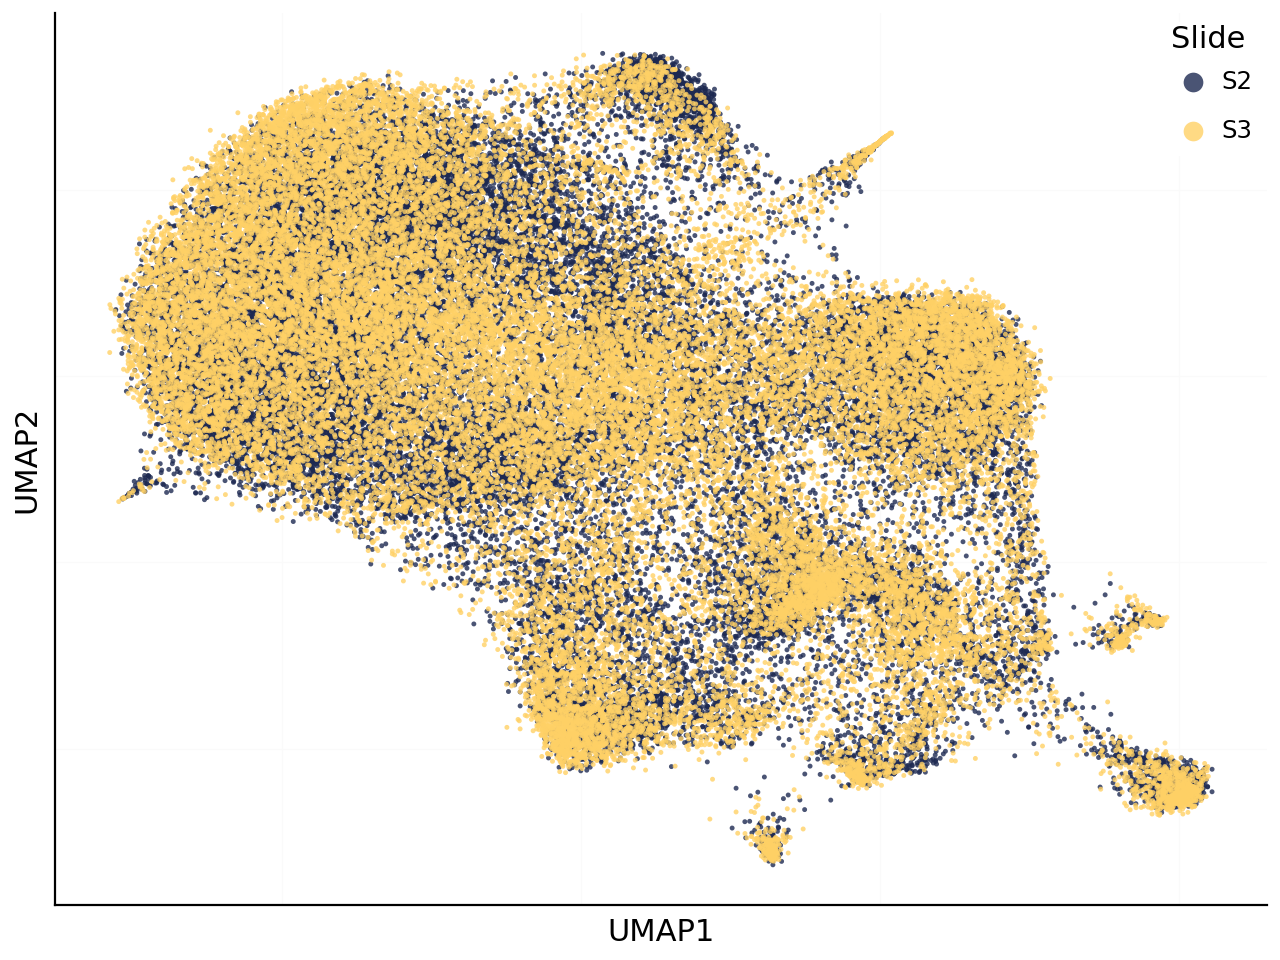

In [8]:
(
    ggplot(latent_umaps, aes(x="umap_1", y="umap_2", fill="slide"))
    + geom_point(alpha=0.8, size=1, stroke=0)
    + scale_fill_manual(values=["#1D2951", "#FFD166"])
    + labs(x="UMAP1", y="UMAP2", fill="Slide")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

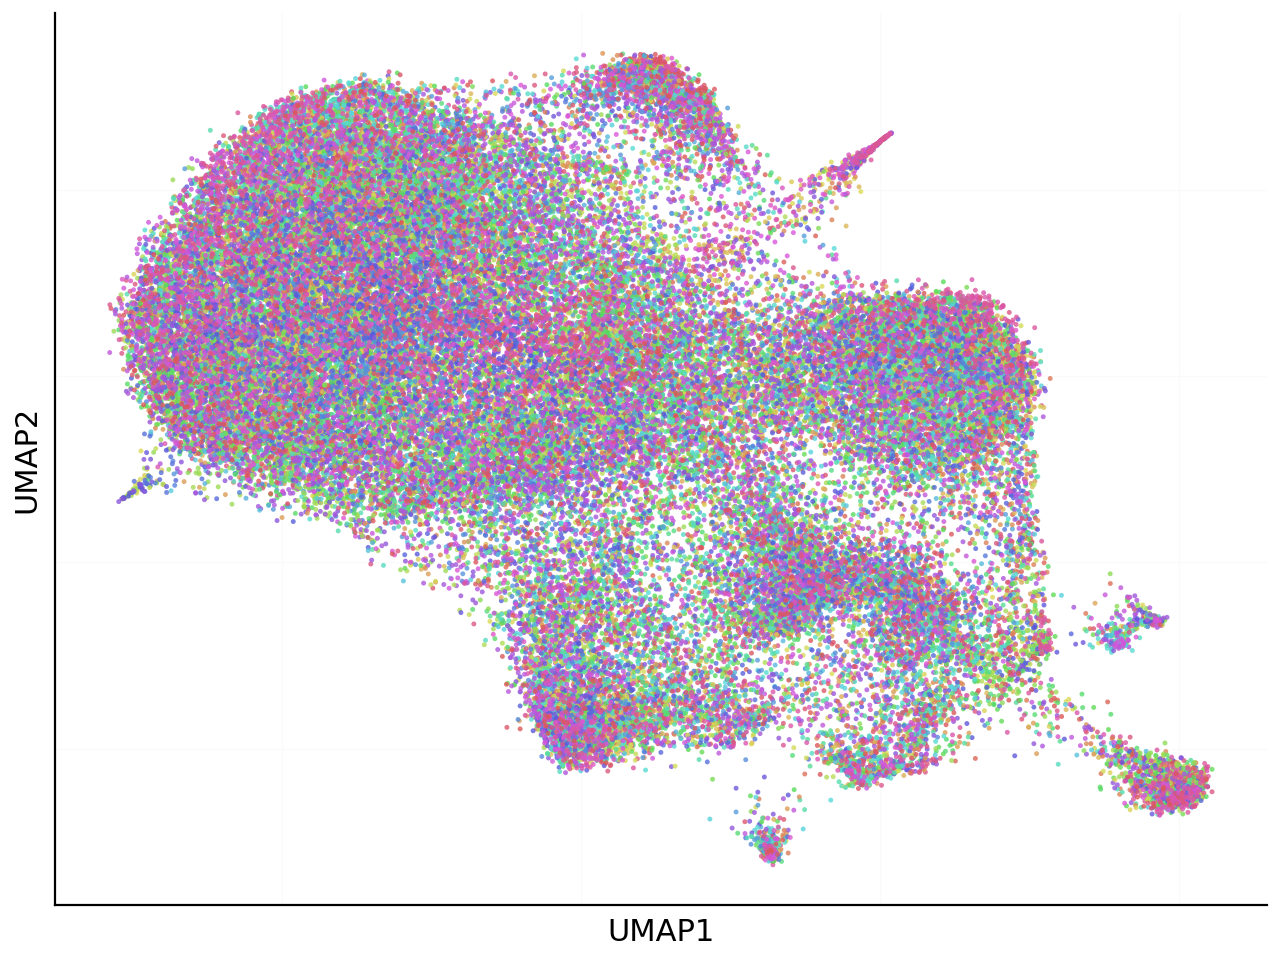

In [9]:
(
    ggplot(latent_umaps, aes(x="umap_1", y="umap_2", fill="fov"))
    + geom_point(alpha=0.8, size=1, stroke=0)
    + labs(x="UMAP1", y="UMAP2")
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position="none",
    )
)

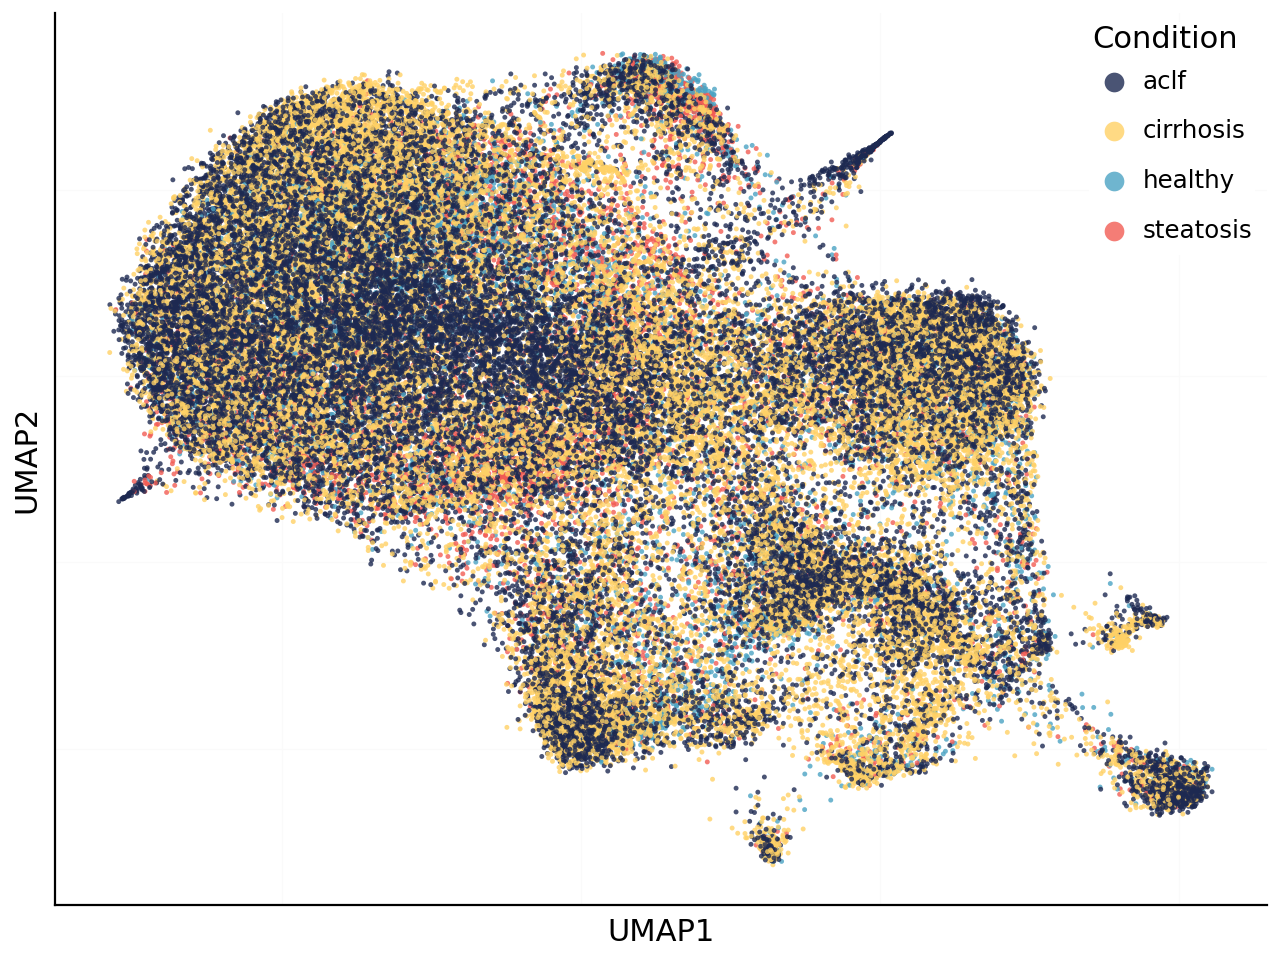

In [10]:
(
    ggplot(latent_umaps, aes(x="umap_1", y="umap_2", fill="condition"))
    + geom_point(alpha=0.8, size=1, stroke=0)
    + scale_fill_manual(values=["#1D2951", "#FFD166", "#4BA3C3", "#F25C54"])
    + labs(x="UMAP1", y="UMAP2", fill="Condition")
    + guides(fill=guide_legend(override_aes={"size": 4}))
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
    )
)

## Plot Normalized Counts

In [11]:
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'slide_colors', 'umap', 'scVI_neighbors'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'scVI_umap'
    varm: 'PCs'
    layers: 'log1p', 'raw', 'scVI_normalized'
    obsp: 'connectivities', 'distances', 'scVI_neighbors_distances', 'scVI_neighbors_connectivities'

In [12]:
sc.pp.pca(adata, layer="scVI_normalized")
adata.obsm["scVI_norm_pca"] = adata.obsm["X_pca"].copy()

sc.pp.neighbors(adata, use_rep="scVI_norm_pca", key_added="scVI_norm_neighbors")

sc.tl.umap(adata, neighbors_key="scVI_norm_neighbors", min_dist=0.1)
adata.obsm["scVI_norm_umap"] = adata.obsm["X_umap"].copy()

In [13]:
df1 = pd.DataFrame(
    adata.obsm["scVI_norm_umap"],
    columns=["umap_1", "umap_2"],
    index=adata.obs_names,
)

# df2 already defined in notebook
norm_umaps = pd.concat([df1, df2], axis=1)
norm_umaps.to_feather(save_dir / "pdata_normalized_umaps.feather")
norm_umaps

,umap_1,umap_2,slide,fov,condition
liver1_3_1,2.319801,7.138608,S2,1_liver1,healthy
liver1_4_1,2.760154,7.177215,S2,1_liver1,healthy
liver1_5_1,2.533922,7.293608,S2,1_liver1,healthy
liver1_7_1,1.075785,11.672855,S2,1_liver1,healthy
liver1_8_1,0.761249,5.514252,S2,1_liver1,healthy
...,...,...,...,...,...
liver2_531_45,-1.399165,8.270365,S3,45_liver2,cirrhosis
liver2_532_45,-5.596869,2.564289,S3,45_liver2,cirrhosis
liver2_533_45,-0.410886,8.459330,S3,45_liver2,cirrhosis
liver2_534_45,-5.262679,2.233997,S3,45_liver2,cirrhosis


Just plot UMAP to see shape.

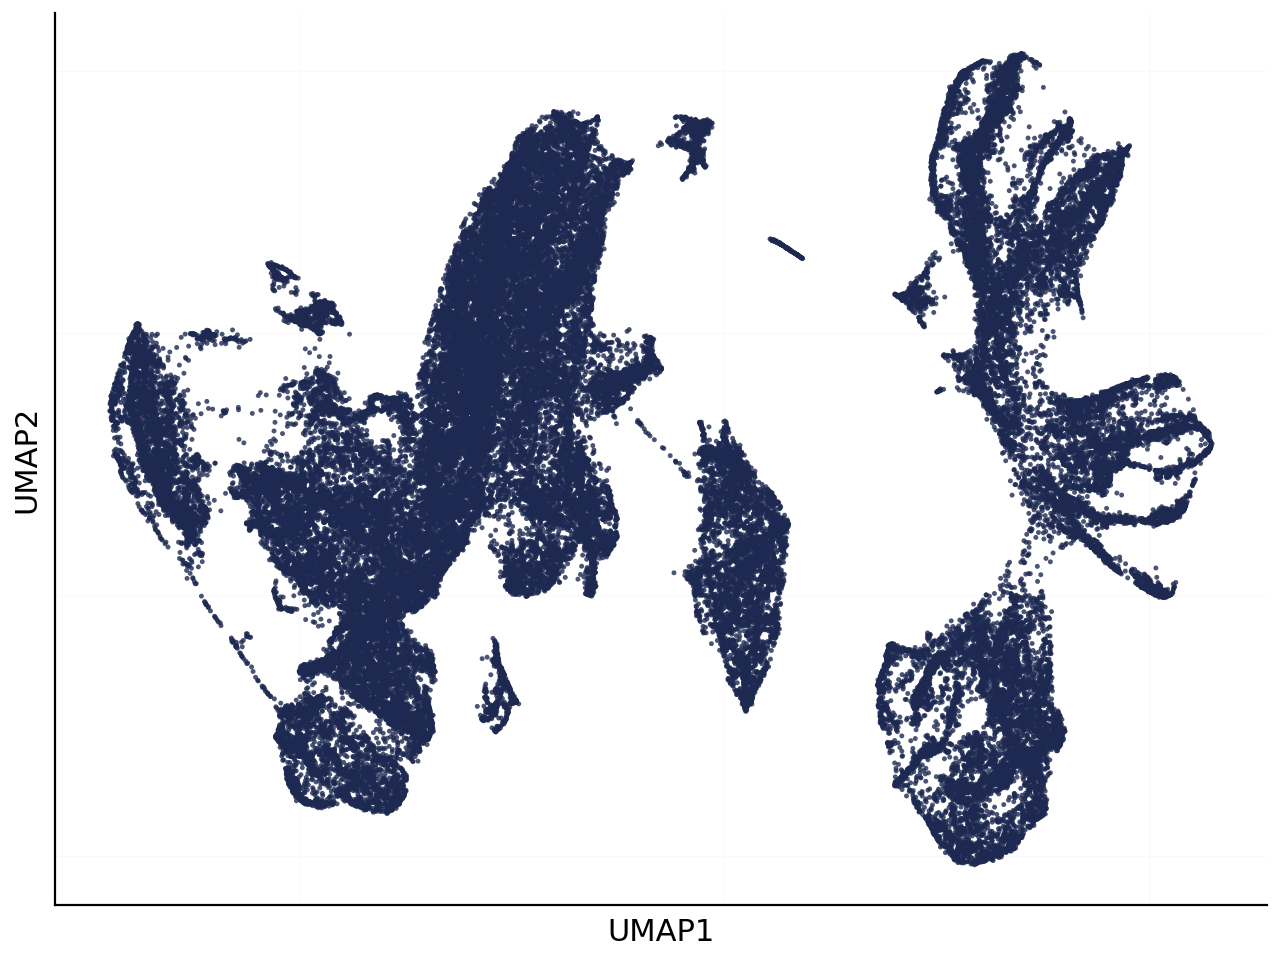

In [14]:
(
    ggplot(norm_umaps, aes(x="umap_1", y="umap_2"))
    + geom_point(alpha=0.8, size=1, stroke=0, fill="#1D2951")
    + labs(x="UMAP1", y="UMAP2")
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

## Perform Clustering

In [15]:
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov', '_scvi_batch', '_scvi_labels'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'disease_state_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'slide_colors', 'umap', 'scVI_neighbors', 'scVI_norm_neighbors'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'log1p_pca', 'log1p_umap', 'scVI_umap', 'scVI_norm_pca', 'scVI_norm_umap'
    varm: 'PCs'
    layers: 'log1p', 'raw', 'scVI_normalized'
    obsp: 'connectivities', 'distances', 'scVI_neighbors_distances', 'scVI_neighbors_connectivities', 'scVI_norm_neighbors_distances', 'scVI_norm_neighbors_connectivities'

### Latent Embedding

In [16]:
# Cluster latent UMAP
sc.tl.leiden(
    adata,
    neighbors_key="scVI_neighbors",
    key_added="scVI_leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

In [17]:
adata.obs["scVI_leiden"].unique()

['0', '2', '7', '1', '3', ..., '8', '6', '4', '9', '10']
Length: 11
Categories (11, object): ['0', '1', '2', '3', ..., '7', '8', '9', '10']

In [18]:
latent_umaps["cluster"] = adata.obs["scVI_leiden"]
latent_umaps.to_feather(save_dir / "pdata_latent_umaps.feather")
latent_umaps

,umap_1,umap_2,slide,fov,condition,cluster
liver1_3_1,0.394357,5.138109,S2,1_liver1,healthy,0
liver1_4_1,-0.264782,8.013857,S2,1_liver1,healthy,2
liver1_5_1,0.288873,7.162090,S2,1_liver1,healthy,7
liver1_7_1,2.196098,1.962305,S2,1_liver1,healthy,7
liver1_8_1,-0.304239,5.262585,S2,1_liver1,healthy,1
...,...,...,...,...,...,...
liver2_531_45,1.105170,5.431719,S3,45_liver2,cirrhosis,0
liver2_532_45,-4.121284,4.813836,S3,45_liver2,cirrhosis,4
liver2_533_45,0.574808,3.216206,S3,45_liver2,cirrhosis,7
liver2_534_45,-3.132342,4.083583,S3,45_liver2,cirrhosis,4


In [19]:
label_positions = (
    latent_umaps.groupby("cluster", observed=True)[["umap_1", "umap_2"]]
    .median()
    .reset_index()
)

label_positions.head(5)

,cluster,umap_1,umap_2
0,0,1.547176,5.031171
1,1,-1.282009,4.783058
2,2,-0.590388,7.954524
3,3,-3.006832,6.915049
4,4,-3.723193,5.201546


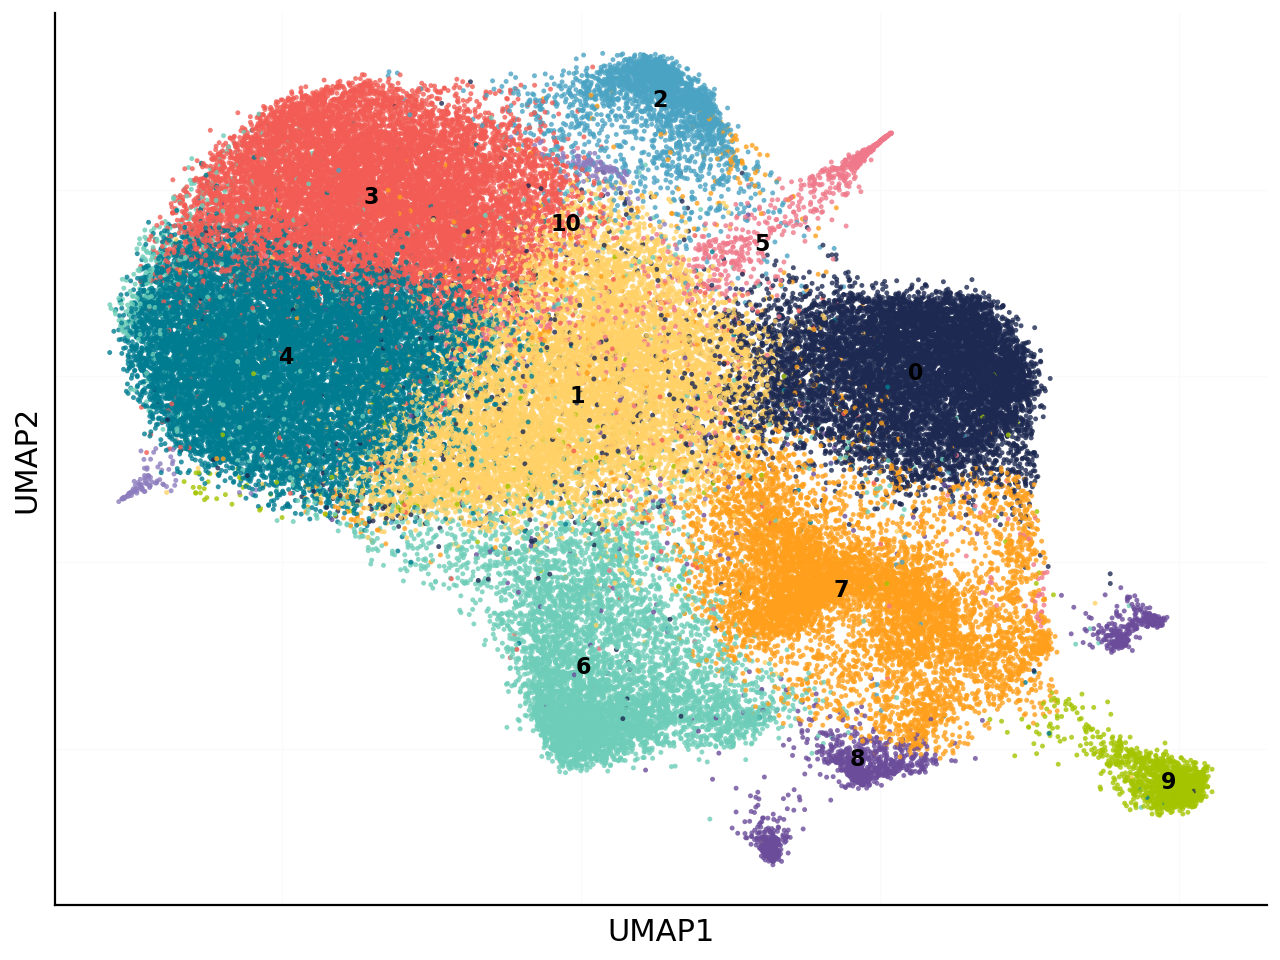

In [20]:
(
    ggplot(latent_umaps, aes(x="umap_1", y="umap_2", fill="cluster"))
    + geom_point(alpha=0.8, size=1, stroke=0)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="cluster"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + scale_fill_manual(
        values=[
            "#1D2951",
            "#FFD166",
            "#4BA3C3",
            "#F25C54",
            "#007C91",
            "#EF798A",
            "#6DCDB8",
            "#FF9F1C",
            "#6B4C9A",
            "#A4C400",
            "#8E7DBE",
        ]
    )
    + guides(fill="none")
    + labs(x="UMAP1", y="UMAP2")
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

### Normalized Counts

In [21]:
# Cluster normalized UMAP
sc.tl.leiden(
    adata,
    neighbors_key="scVI_norm_neighbors",
    key_added="scVI_norm_leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

In [22]:
adata.obs["scVI_norm_leiden"].unique()

['0', '12', '13', '11', '2', ..., '31', '32', '34', '26', '33']
Length: 35
Categories (35, object): ['0', '1', '2', '3', ..., '31', '32', '33', '34']

In [23]:
norm_umaps["cluster"] = adata.obs["scVI_norm_leiden"]
norm_umaps.to_feather(save_dir / "pdata_normalized_umaps.feather")
norm_umaps

,umap_1,umap_2,slide,fov,condition,cluster
liver1_3_1,2.319801,7.138608,S2,1_liver1,healthy,0
liver1_4_1,2.760154,7.177215,S2,1_liver1,healthy,0
liver1_5_1,2.533922,7.293608,S2,1_liver1,healthy,0
liver1_7_1,1.075785,11.672855,S2,1_liver1,healthy,12
liver1_8_1,0.761249,5.514252,S2,1_liver1,healthy,13
...,...,...,...,...,...,...
liver2_531_45,-1.399165,8.270365,S3,45_liver2,cirrhosis,3
liver2_532_45,-5.596869,2.564289,S3,45_liver2,cirrhosis,7
liver2_533_45,-0.410886,8.459330,S3,45_liver2,cirrhosis,3
liver2_534_45,-5.262679,2.233997,S3,45_liver2,cirrhosis,7


In [24]:
label_positions = (
    norm_umaps.groupby("cluster", observed=True)[["umap_1", "umap_2"]]
    .median()
    .reset_index()
)

label_positions.head(5)

,cluster,umap_1,umap_2
0,0,2.306053,6.734900
1,1,-1.031849,5.916659
2,2,-8.741589,6.233697
3,3,-0.485265,8.727466
4,4,0.443786,9.780798


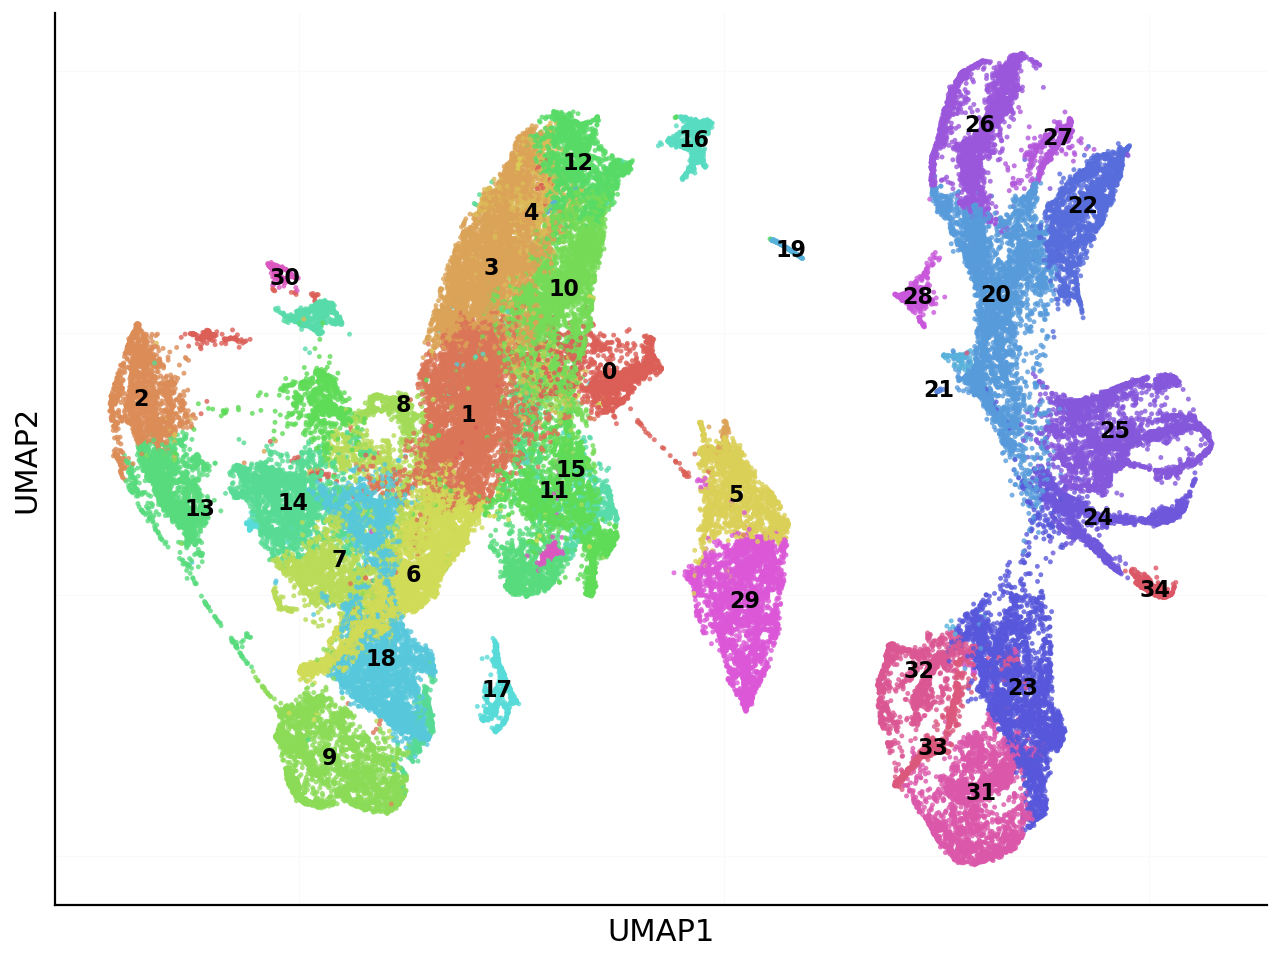

In [25]:
(
    ggplot(norm_umaps, aes(x="umap_1", y="umap_2", fill="cluster"))
    + geom_point(alpha=0.8, size=1, stroke=0)
    + geom_text(
        label_positions,
        aes("umap_1", "umap_2", label="cluster"),
        size=8,
        fontweight="bold",
        color="black",
    )
    + guides(fill="none")
    + labs(x="UMAP1", y="UMAP2")
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major=element_blank(),
        axis_line=element_line(color="#000000", size=0.8),
        axis_text=element_blank(),
        axis_ticks=element_blank(),
    )
)

## Save AnnData

In [26]:
adata.write(adata_file, compression="gzip")